<a href="https://colab.research.google.com/github/shunrei9841-sudo/Guadalupe/blob/main/Ejercicio%205.5.13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 5.5.13


$$
\frac{d^2 u}{dx^2} + u = x^2, \qquad 0 < x < 1
$$


**Casos:**

(i)  
$$
u(0)=0, \qquad u(1)=0
$$

(ii)  
$$
u(0)=0, \qquad u'(1)=1
$$

usando el **método de Galerkin**.


La formulación débil del problema es:


$$
\int_0^1 \left(-u'v' + uv\right)\,dx
=
\int_0^1 x^2 v\,dx
\quad \text{(caso i)}
$$


Para el caso (ii), la condición natural introduce el término de frontera:


$$
\int_0^1 \left(-u'v' + uv\right)\,dx
=
\int_0^1 x^2 v\,dx + v(1)
$$


In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
x = sp.symbols('x')

# Número de funciones base
N = 3


In [3]:
# Funciones base seno (cumplen u(0)=0)
phi = [sp.sin((i+1)*sp.pi*x) for i in range(N)]


In [4]:
A1 = sp.zeros(N, N)
b1 = sp.zeros(N, 1)

for i in range(N):
    for j in range(N):
        A1[i, j] = sp.integrate(
            -sp.diff(phi[j], x)*sp.diff(phi[i], x) + phi[j]*phi[i],
            (x, 0, 1)
        )
    b1[i] = sp.integrate(x**2 * phi[i], (x, 0, 1))


In [5]:
A2 = A1.copy()
b2 = sp.zeros(N, 1)

for i in range(N):
    b2[i] = sp.integrate(x**2 * phi[i], (x, 0, 1)) + phi[i].subs(x, 1)


In [6]:
# Coeficientes
c1 = A1.LUsolve(b1)   # Caso (i)
c2 = A2.LUsolve(b2)   # Caso (ii)

c1, c2


(Matrix([
 [           (-4/pi**3 + 1/pi)/(1/2 - pi**2/2)],
 [                   -1/(2*pi*(1/2 - 2*pi**2))],
 [(-4/(27*pi**3) + 1/(3*pi))/(1/2 - 9*pi**2/2)]]),
 Matrix([
 [           (-4/pi**3 + 1/pi)/(1/2 - pi**2/2)],
 [                   -1/(2*pi*(1/2 - 2*pi**2))],
 [(-4/(27*pi**3) + 1/(3*pi))/(1/2 - 9*pi**2/2)]]))

In [7]:
u1 = sum(c1[i]*phi[i] for i in range(N))
u2 = sum(c2[i]*phi[i] for i in range(N))

u1 = sp.simplify(u1)
u2 = sp.simplify(u2)

u1, u2


((-2*(1 - 9*pi**2)*(1 - 4*pi**2)*(4 - pi**2)*sin(pi*x) - pi**2*(1 - 9*pi**2)*(1 - pi**2)*sin(2*pi*x) - 2*(1 - 4*pi**2)*(1 - pi**2)*(4 - 9*pi**2)*sin(3*pi*x)/27)/(pi**3*(1 - 9*pi**2)*(1 - 4*pi**2)*(1 - pi**2)),
 (-2*(1 - 9*pi**2)*(1 - 4*pi**2)*(4 - pi**2)*sin(pi*x) - pi**2*(1 - 9*pi**2)*(1 - pi**2)*sin(2*pi*x) - 2*(1 - 4*pi**2)*(1 - pi**2)*(4 - 9*pi**2)*sin(3*pi*x)/27)/(pi**3*(1 - 9*pi**2)*(1 - 4*pi**2)*(1 - pi**2)))

In [8]:
u1_num = sp.lambdify(x, u1, 'numpy')
u2_num = sp.lambdify(x, u2, 'numpy')

x_vals = np.linspace(0, 1, 200)

u1_vals = u1_num(x_vals)
u2_vals = u2_num(x_vals)


In [9]:
tabla = pd.DataFrame({
    'x': x_vals[::20],
    'u_caso_i': u1_vals[::20],
    'u_caso_ii': u2_vals[::20]
})

tabla


,x,u_caso_i,u_caso_ii
0,0.000000,-0.000000,-0.000000
1,0.100503,-0.010244,-0.010244
2,0.201005,-0.019503,-0.019503
3,0.301508,-0.027491,-0.027491
4,0.402010,-0.034510,-0.034510
5,0.502513,-0.040508,-0.040508
6,0.603015,-0.044156,-0.044156
7,0.703518,-0.042962,-0.042962
8,0.804020,-0.034672,-0.034672
9,0.904523,-0.019090,-0.019090


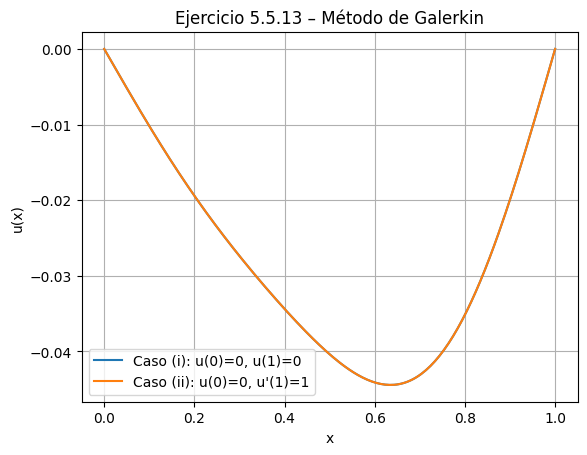

In [10]:
plt.figure()
plt.plot(x_vals, u1_vals, label='Caso (i): u(0)=0, u(1)=0')
plt.plot(x_vals, u2_vals, label='Caso (ii): u(0)=0, u\'(1)=1')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Ejercicio 5.5.13 – Método de Galerkin')
plt.legend()
plt.grid()
plt.show()
